In [1]:
import torch
import torchvision
import torch.nn as nn

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Автокодировщик

основная модель MNIST-MNIST

In [68]:
class Encoder(nn.Module):
        
    def __init__(self, hiden_size, im_size):
        super(Encoder, self).__init__()
        self.im_size = im_size
        self.hiden_size = hiden_size
        print(self.im_size)
        self.c1 = blocc(self.im_size[0], hiden_size * 2, hiden_size, 3)
        self.p1 = nn.MaxPool2d(2,2)
        self.c2 = blocc(hiden_size * 2, hiden_size * 4, hiden_size * 4, 3)
        self.p2 = nn.MaxPool2d(2,2)
        self.c3 = blocc(hiden_size * 4, hiden_size * 8, hiden_size * 8, 3)
        self.p3 = nn.MaxPool2d(2,2)
        self.latent = nn.Linear((im_size[1] // 8) * (im_size[2] // 8) * hiden_size * 8, hiden_size * 8 )
        
    def forward(self, input):
        #print('input ',input.shape)
        x = self.c1(input)
        x = self.p1(x)
        #print('e:b1 ',x.shape)
        x = self.c2(x)
        x = self.p2(x)
        #print('e:b2 ',x.shape)
        x = self.c3(x)
        x = self.p3(x)
        #print('e:b3 ',x.reshape(input.shape[0], -1,).shape, (self.im_size[0] // 8) * (self.im_size[1] // 8) * self.hiden_size * 8, self.hiden_size * 8 )
        x = self.latent(x.reshape(input.shape[0], -1,))
        #print('e:l ',x.shape)
        return x

def blocc( h1, h2, hiden_size, kernel):
    return nn.Sequential(nn.Conv2d(h1, hiden_size, kernel, padding=1), 
                         nn.BatchNorm2d(hiden_size), nn.ReLU(), 
                         nn.Conv2d(hiden_size, h2, kernel, padding=1), 
                         nn.BatchNorm2d(h2), nn.ReLU())       
class Decoder(nn.Module):
    
        
    def __init__(self, hiden_size, im_size):
        super(Decoder, self).__init__()
        self.im_size = im_size
        self.hiden_size = hiden_size
        #print(self.im_size)
        self.latent = nn.Linear(hiden_size * 8, (im_size[2] // 8) * (im_size[1] // 8) * hiden_size * 8, )
        # im_size[1] // 8, im_size[1] // 8,  hiden_size * 8
        self.c3 = blocc(hiden_size * 8, hiden_size * 4, hiden_size * 8, 3)
        self.p3 = nn.ConvTranspose2d( hiden_size * 4, hiden_size * 4, kernel_size=4, stride=2, padding=0)# (in_channels: int, out_channels: int, kernel_size: Union[int, Tuple[int, int]], stride
        
        self.c2 = blocc(hiden_size * 4, hiden_size * 2, hiden_size * 4, 3)
        self.p2 = nn.ConvTranspose2d( hiden_size * 2, hiden_size * 2, kernel_size=4, stride=2, padding=0)# (in_channels: int, out_channels: int, kernel_size: Union[int, Tuple[int, int]], stride
        
        self.c1 = blocc(hiden_size * 2, hiden_size * 2, hiden_size * 2, 3)
        self.p1 = nn.ConvTranspose2d( hiden_size * 2, hiden_size, kernel_size=4, stride=2, padding=0)# (in_channels: int, out_channels: int, kernel_size: Union[int, Tuple[int, int]], stride

        self.c0 = nn.Conv2d(hiden_size, self.im_size[0], 3, padding=1)
        self.out = nn.Sigmoid()
        
    def forward(self, input):
        #print(input.shape)
        x = self.latent(input)
        x = x.reshape(input.shape[0], self.hiden_size * 8,self.im_size[1]//8,self.im_size[2]//8)
        #print('latent ',x.shape)
        x = self.c3(x)
        x = self.p3(x)
        #print('d:b3 ',x.shape)
        
        x = self.c2(x)
        x = self.p2(x)
        #print('d:b2 ',x.shape)
        
        x = self.c1(x)
        x = self.p1(x)
        #print('d:b1 ',x.shape)

        x = self.c0(x)
        #print('d:out ',x.shape)
        
        return self.out(x)
        
class Autoencoder_Base(nn.Module):
    def __init__(self, hiden_size, im_size):
        super(Autoencoder_Base, self).__init__()
        self.encoder = Encoder(hiden_size, im_size)
        self.decoder = Decoder(hiden_size, im_size)
    def forward(self, input):
        #print(input.shape)
        return self.decoder(self.encoder(input))
        
    

In [69]:
AE = Autoencoder_Base(8,[1,28,28])

[1, 28, 28]


In [70]:
AE(torch.ones(1,1,28,28))

tensor([[[[0.4817, 0.4740, 0.4510,  ..., 0.4611, 0.4620, 0.4642],
          [0.5133, 0.4953, 0.4761,  ..., 0.4981, 0.4658, 0.4821],
          [0.5047, 0.5005, 0.4722,  ..., 0.4413, 0.4384, 0.4541],
          ...,
          [0.4821, 0.4846, 0.4525,  ..., 0.5172, 0.4509, 0.4777],
          [0.4871, 0.4863, 0.4795,  ..., 0.4819, 0.4956, 0.4760],
          [0.4752, 0.4757, 0.4645,  ..., 0.4790, 0.4721, 0.4764]]]],
       grad_fn=<SigmoidBackward0>)

Читаем MNIST

In [74]:
import sklearn as sk

In [75]:
from sklearn.datasets import fetch_lfw_people

In [ ]:
V = fetch_lfw_people()

In [77]:
ds = torchvision.datasets.MNIST(root='./', train=True, download=True) 

100%|████████████████████████████| 9912422/9912422 [00:01<00:00, 9817813.60it/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw



100%|███████████████████████████████| 28881/28881 [00:00<00:00, 23548929.59it/s]

Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw



100%|████████████████████████████| 1648877/1648877 [00:00<00:00, 6257926.72it/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw



100%|██████████████████████████████████| 4542/4542 [00:00<00:00, 6431643.74it/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



In [71]:
help(torchvision.datasets.MNIST)

Help on class MNIST in module torchvision.datasets.mnist:

class MNIST(torchvision.datasets.vision.VisionDataset)
 |  MNIST(root: str, train: bool = True, transform: Optional[Callable] = None, target_transform: Optional[Callable] = None, download: bool = False) -> None
 |  
 |  `MNIST <http://yann.lecun.com/exdb/mnist/>`_ Dataset.
 |  
 |  Args:
 |      root (string): Root directory of dataset where ``MNIST/raw/train-images-idx3-ubyte``
 |          and  ``MNIST/raw/t10k-images-idx3-ubyte`` exist.
 |      train (bool, optional): If True, creates dataset from ``train-images-idx3-ubyte``,
 |          otherwise from ``t10k-images-idx3-ubyte``.
 |      download (bool, optional): If True, downloads the dataset from the internet and
 |          puts it in root directory. If dataset is already downloaded, it is not
 |          downloaded again.
 |      transform (callable, optional): A function/transform that  takes in an PIL image
 |          and returns a transformed version. E.g, ``transfor

In [ ]:
(xTrainMnist, yTrainMnist), (xTestMnist, yTestMnist) = mnist.load_data()

noice =1

xTrainMnist = xTrainMnist.astype('float32')/255

xTrainMnist = xTrainMnist.reshape(xTrainMnist.shape[0], 28, 28, 1)

yTrainMnist_pix = xTrainMnist.copy()
xTrainMnist += np.random.randn(xTrainMnist.shape[0],xTrainMnist.shape[1],xTrainMnist.shape[2],xTrainMnist.shape[3]) * noice

11493376/11490434 [==============================] - 2s 0us/step


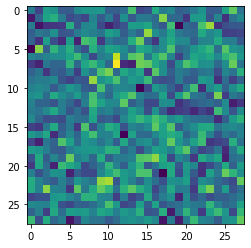

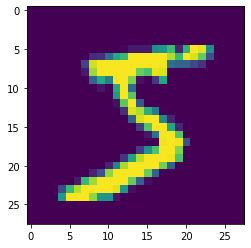

In [ ]:
plt.imshow(xTrainMnist[0,:,:,0])
plt.show()
plt.imshow(yTrainMnist_pix[0,:,:,0])
plt.show()

Собираем модель


In [ ]:
modelAutoMnist, m0 = base_model_Autoencoder(level = 2, input_size=(28,28,1), kernel_list=[32,64])













(?, 7, 7, 64)



In [ ]:

#modelAutoMnist = denoiseAutoencoder()
hist=modelAutoMnist.fit(xTrainMnist[:10000], yTrainMnist_pix[:10000], epochs=10, batch_size=100, validation_split=0.2)



Train on 8000 samples, validate on 2000 samples
Epoch 1/10
8000/8000 [==============================] - 13s 2ms/step - loss: 0.0713 - acc: 0.7730 - val_loss: 0.0413 - val_acc: 0.7958
Epoch 2/10
8000/8000 [==============================] - 5s 602us/step - loss: 0.0353 - acc: 0.8037 - val_loss: 0.0345 - val_acc: 0.8046
Epoch 3/10
8000/8000 [==============================] - 5s 597us/step - loss: 0.0312 - acc: 0.8048 - val_loss: 0.0329 - val_acc: 0.8069
Epoch 4/10
8000/8000 [==============================] - 5s 596us/step - loss: 0.0295 - acc: 0.8053 - val_loss: 0.0326 - val_acc: 0.8080
Epoch 5/10
8000/8000 [==============================] - 5s 598us/step - loss: 0.0282 - acc: 0.8057 - val_loss: 0.0316 - val_acc: 0.8080
Epoch 6/10
8000/8000 [==============================] - 5s 597us/step - loss: 0.0274 - acc: 0.8060 - val_loss: 0.0311 - val_acc: 0.8079
Epoch 7/10
8000/8000 [==============================] - 5s 602us/step - loss: 0.0266 - acc: 0.8063 - val_loss: 0.0290 - val_acc: 0.8058

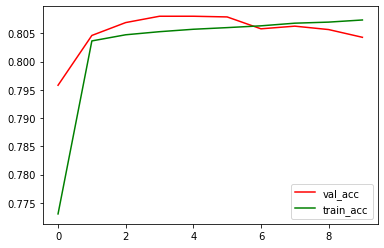

In [ ]:
plt.plot(hist.history['val_acc'],'r',label='val_acc')
plt.plot(hist.history['acc'],'g',label='train_acc')
plt.legend()
plt.show()

In [ ]:
modelAutoMnist.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 28, 28, 1)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 32)        320       
_________________________________________________________________
batch_normalization_1 (Batch (None, 28, 28, 32)        128       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
batch_normalization_2 (Batch (None, 28, 28, 32)        128       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 14, 14, 64)        1849

In [ ]:
mask = np.where(yTrainMnist == 0)

y_pred=modelAutoMnist.predict(xTrainMnist[mask[0]])

ff=m0.predict(xTrainMnist[mask[0]])
print(ff.shape)

ff = np.mean(ff, axis=0)
print(ff.shape)



(5923, 7, 7, 64)
(7, 7, 64)


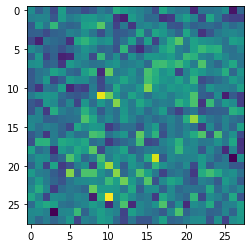

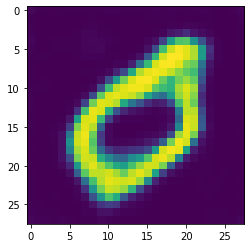

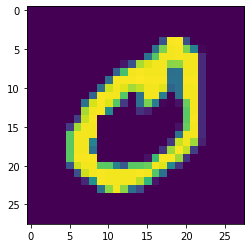

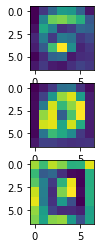

In [ ]:
plt.imshow(xTrainMnist[mask[0]][1,:,:,0])
plt.show()
plt.imshow(y_pred[1,:,:,0])
plt.show()
plt.imshow(yTrainMnist_pix[mask[0]][1,:,:,0])
plt.show()

g1=ff[:,:,0]
plt.subplot(311)
plt.imshow(g1)
g1=ff[:,:,1]
plt.subplot(312)
plt.imshow(g1)
g1=ff[:,:,2]
plt.subplot(313)
plt.imshow(g1)
plt.show()

In [ ]:
def vis_layer(ff,list_kernel):
  for i in range(len(list_kernel)):
    #print(list_kernel[i])
    plt.subplot(311+i)
    g1=ff[:,:,list_kernel[i]]
    plt.imshow(g1)
  
  plt.show()
  

# Визуализация слоев

средний объект - идеал??? 

(5923, 28, 28, 32)
(28, 28, 32)


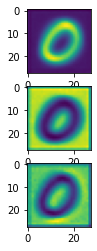

In [ ]:
activ_model_layer = Model(inputs=modelAutoMnist.input, outputs = modelAutoMnist.layers[3].output)

ff = activ_model_layer.predict(xTrainMnist[mask[0]])


print(ff.shape)


ff = np.mean(ff, axis=0)
print(ff.shape)

vis_layer(ff,[0,2,5])

In [ ]:
(xT_fash, yT_fash), (xTest_f, yTest_f) = fashion_mnist.load_data()

noice =0.35

xT_fash = xT_fash.astype('float32')/255

xT_fash = xT_fash.reshape(xT_fash.shape[0], 28, 28, 1)

xT_fash += np.random.randn(xT_fash.shape[0],xT_fash.shape[1],xT_fash.shape[2],xT_fash.shape[3]) * noice



4423680/4422102 [==============================] - 2s 0us/step


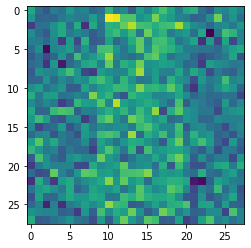

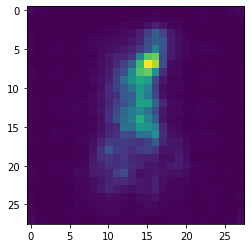

In [ ]:
y_pred=modelAutoMnist.predict(xT_fash[:20])
N=2
plt.imshow(xT_fash[N,:,:,0])
plt.show()
plt.imshow(y_pred[N,:,:,0])
plt.show()
